In [1]:
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path

# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

# Add the 'scripts' directory to sys.path to be able to import data_utils.py
sys.path.append(str(current_dir))

from scripts.data_utils import split_summary_methods, format_mean_std
import ast  
import matplotlib.pyplot as plt
import seaborn as sns
from autorank import autorank, plot_stats, create_report

pd.set_option('display.max_colwidth', None)

/home/nicolas/spectral_anomaly_detector/scripts/data_utils.py:2: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


In [2]:
MAX_NUMBER_OF_RUNS_STOCASTIC = 3

TYPE_WS = "params_with_p_window_size" #params_with_p_window_size or params_with_window


#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4.xlsx")
data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4_bv5_inv_score.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pv_bv5_for_fplasma_fcurrent_pv.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pv_bv5_with_current_gtv2_ds.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_mgragstream_and_own_method_eval_public_ds.xlsx")

# Reading PV dataset showing all hyperparameters considered
#order_pv = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9','SA1', 'SA2', 'SA3','DA1', 'DA2', 'DA3','TA1', 'TA2', 'TA3']

# Reading Public dataset showing all hyperparameters considered
#order_pds = ['551', '171', '115', '137', '116']

#concatenated_order = order_pv + order_pds

#data = pd.concat([data_sota_pv, data_sota_pds])
#data = data_sota_eval_pds
data['cod_scenario'] = data['cod_scenario'].astype(str)
#data['scenario'] = pd.Categorical(data['scenario'], categories=concatenated_order, ordered=True)

data['method_window_and_param'] = data['method_window_and_param'].str.replace("SWKNN_own", "SWKNN(own)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case1", "pmDragStream(Case1)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case2", "pmDragStream(Case2)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case3", "pmDragStream(Case3)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case4", "pmDragStream(Case4)")

data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case1", "smDragStream(Case1)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case2", "smDragStream(Case2)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case3", "smDragStream(Case3)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case4", "smDragStream(Case4)")

data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TNone", "OBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TZnorm", "OBKNN (TZNorm)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("SFOnlineBootKNN_TNone", "SFOBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("SFOnlineBootKNN_TZnorm", "SFOBKNN (TZNorm)")


data['code_and_name_scenario'] = data['cod_scenario'] +"_"+ data['name_scenario'].astype(str)

data.method_window_and_param.unique()



array(["oIF_2000_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",
       "RobustRandomCutForest_2000_{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}",
       "KitNet_500_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",
       "HStree_200_{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}",
       "xStream_200_{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",
       "ExactStorm_2000_{'max_radius': 900, 'p_window_size': 0.2}",
       "RSHash_2000_{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",
       "SWLOF_200_{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}",
       "IForestASD_2000_{'initial_window_X': None, 'p_window_size': 0.2}",
       "RobustRandomCutForest_5696

In [3]:
data.columns

Index(['iteration', 'cod_scenario', 'name_scenario', 'method_window_and_param',
       'p_window_size', 'window_size', 'raw_roc_auc', 'raw_pr_auc',
       'raw_max_f1', 'raw_roc_auc_wtd', 'raw_pr_auc_wtd', 'raw_max_f1_wtd',
       'raw_pct_detection', 'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp',
       'best_threshold', 'auc_roc', 'auc_pr', 'precision', 'f_metric',
       'precision_at_k', 'rprecision', 'rrecall', 'rf', 'r_auc_roc',
       'r_auc_pr', 'vus_roc', 'vus_pr', 'affiliation_precision',
       'affiliation_recall', 'mean_training_time', 'max_training_time',
       'min_training_time', 'mean_scoring_time', 'max_scoring_time',
       'min_scoring_time', 'count_cleaned_score', 'count_raw_score',
       'count_anomalies', 'count_normal', 'code_and_name_scenario'],
      dtype='object')

In [4]:
# Find duplicates for the same iteration and the same experiment
duplicates = data[["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].duplicated(keep=False)
data[duplicates][["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].sort_values(by=["method_window_and_param"])

,iteration,cod_scenario,method_window_and_param,count_cleaned_score


In [5]:
# Summary of datasets used
pivot = data.pivot_table(values=["count_cleaned_score", "count_anomalies"], index=["cod_scenario"], aggfunc='mean')
pivot['percentage_anomalies'] = (pivot['count_anomalies'] / pivot['count_cleaned_score']) * 100
pivot


,count_anomalies,count_cleaned_score,percentage_anomalies
cod_scenario,,,
001,50.0,16220.0,0.308261
002,11.0,1827.0,0.602080
018,2306.0,38774.0,5.947284
019,18610.0,150000.0,12.406667
032,1850.0,200001.0,0.924995
...,...,...,...
TA1,300.0,4200.0,7.142857
TA2,300.0,4200.0,7.142857
TA3,120.0,9000.0,1.333333


In [6]:
original_benchmark = {
    "A1", "A2", "A3", "A4", "A5", "A6",
    "A7", "A8", "A9"
}

bv4 = {
    "SA1", "SA2", "SA3",
    "TA1", "TA2", "TA3",
    "DA1", "DA2", "DA3"
}

bv5 = {
    "RNH", "RAR", "RMX",
    "HNH", "HAR",
    "LNH", "LAR",
    "TNH", "TAR",
    "SAR1", "SAR2", "SAR3"
}

def benchmark_flag(code):
    if code in original_benchmark:
        return "Original Spectral Benchmark"
    elif code in bv4:
        return "BV4"
    elif code in bv5:
        return "BV5"
    else:
        return "Unknown"

data["benchmark"] = data["cod_scenario"].apply(benchmark_flag)

In [7]:
# Adjusting format and creating new columns for analysis in the dataset read

# Extracting new columns for the method, window_size, parameters
data[['method',"window_size", 'parameters']] = data['method_window_and_param'].apply(
    lambda x: pd.Series(split_summary_methods(x))
)

# Creating new column params_with_window
data["params_with_p_window_size"] = data["parameters"]
data["params_with_p_window_size"] = data["params_with_p_window_size"].str.replace("}_{", ",", regex=False)

data["params_with_window"] = "{'window_size': " + data["window_size"].astype(str)+data["parameters"].str.replace("{", ", ", regex=False)
data["params_with_window"] = data["params_with_window"].str.replace("}_{", ",", regex=False)

# Define your list of non-stochastic methods
non_stochastic_methods = ["SWKNN", "SWKNN_own", "SWLOF", "KitNet", "ExactStorm", "mDragStream","SFSWKNN", "SFSWKNN_own", "SFSWLOF", "SFKitNet", "SFExactStorm", "SFmDragStream"]

# Create the 'stochastic' column
data['stochastic'] = data['method'].apply(
    lambda x: 'N' if x in non_stochastic_methods else 'Y')


# Create the 'public' dataset column
data['public'] = np.where(data['cod_scenario'].str.isdigit(), 'Y', 'N')

# Shortening the name of the methods
new_method_name = {"xStream":"XStream", 
"RSHash":"RSHash", "IForestASD":"IFASD", "RobustRandomCutForest":"RRCF", "KitNet":"KitNet", "ExactStorm":"EStorm","oIF":"OIF", "HStree":"HStree", "OnlineBootKNN":"OBKNN",
"SFxStream":"SFXStream", 
"SFRSHash":"SFRSHash", "SFIForestASD":"SFIFASD", "SFRobustRandomCutForest":"SFRRCF", "SFKitNet":"SFKitNet", "SFExactStorm":"SFEStorm","SFoIF":"SFOIF", "SFHStree":"SFHStree", "SFOnlineBootKNN":"SFOBKNN"
} 

data["method"] = data['method'].replace(new_method_name)
data["method_with_param"] = data['method']+"_"+data["parameters"]

# Flag for mDrastream
is_drag = data['method'].isin(['mDragStream'])
is_drag1 = data['method'].isin(['pmDragStream(Case1)'])
is_drag2 = data['method'].isin(['pmDragStream(Case2)'])
is_drag3 = data['method'].isin(['pmDragStream(Case3)'])
is_drag4 = data['method'].isin(['pmDragStream(Case4)'])

is_sdrag1 = data['method'].isin(['smDragStream(Case1)'])
is_sdrag2 = data['method'].isin(['smDragStream(Case2)'])
is_sdrag3 = data['method'].isin(['smDragStream(Case3)'])
is_sdrag4 = data['method'].isin(['smDragStream(Case4)'])


is_euc = data['params_with_window'].str.contains('euclidean', case=False, na=False)
is_mah = data['params_with_window'].str.contains('mahalanobis', case=False, na=False)

data['method'] = np.select(
    [is_drag & is_euc, is_drag & is_mah, is_drag1 & is_euc, is_drag1 & is_mah,is_drag2 & is_euc, is_drag2 & is_mah, is_drag3 & is_euc, is_drag3 & is_mah, is_drag4 & is_euc, is_drag4 & is_mah], 
    ['mDragStream (Euc)', 'mDragStream (Mah)','mDragStream Case 1 (Euc)', 'mDragStream Case 1 (Mah)','mDragStream Case 2 (Euc)', 'mDragStream Case 2 (Mah)','mDragStream Case 3 (Euc)', 'mDragStream Case 3 (Mah)','mDragStream Case 4 (Euc)', 'mDragStream Case 4 (Mah)'], 
    default=data['method']
)

data['method'] = np.select(
    [is_sdrag1 & is_euc, is_sdrag1 & is_mah,is_sdrag2 & is_euc, is_sdrag2 & is_mah, is_sdrag3 & is_euc, is_sdrag3 & is_mah, is_sdrag4 & is_euc, is_sdrag4 & is_mah], 
    ['subsequencemDragStream Case 1 (Euc)', 'subsequencemDragStream Case 1 (Mah)','subsequencemDragStream Case 2 (Euc)', 'subsequencemDragStream Case 2 (Mah)','subsequencemDragStream Case 3 (Euc)', 'subsequencemDragStream Case 3 (Mah)','subsequencemDragStream Case 4 (Euc)', 'subsequencemDragStream Case 4 (Mah)'], 
    default=data['method']
)

#Separating OnlineBootKNN with None, Z-normalization or SQRT transformation
# Case 1: None
mask_none = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('NONE', case=False, na=False))
data.loc[mask_none, 'method'] = 'OBKNN (None)'

# Case 2: ZNormalization
mask_znorm = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('ZNORM', case=False, na=False))
data.loc[mask_znorm, 'method'] = 'OBKNN (ZNorm)'

# Case 2: ZNormalization
mask_sqrt = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('SQRT', case=False, na=False))
data.loc[mask_sqrt, 'method'] = 'OBKNN (TSqrt)'

# Including the year of publication of the methods
method_and_year = {
"XStream":"2018", 
"RSHash":"2011", "IFASD":"2013", "RRCF":"2016", "KitNet":"2018", "EStorm":"2007","OIF":"2024", "HStree":"2011", 
"OBKNN (TNone)":"2025", "OBKNN (TZNorm)":"2025", "BKNN":"2025", "SWKNN":"2000","SWLOF":"2000", 
"SWKNN_own":"2025", "mDragStream (Mah)":"2025", "mDragStream (Euc)":"2025",
"SFXStream":"2018", 
"SFRSHash":"2011", "SFIFASD":"2013", "SFRRCF":"2016", "SFKitNet":"2018", "SFEStorm":"2007","SFOIF":"2024", "SFHStree":"2011", 
"SFOBKNN (TNone)":"2025", "SFOBKNN (TZNorm)":"2025", "SFBKNN":"2025", "SFSWKNN":"2000","SFSWLOF":"2000", 
"SFSWKNN_own":"2025", "SFmDragStream (Mah)":"2025", "SFmDragStream (Euc)":"2025",

} 
data["method_and_year"] = data['method'].map(lambda x: f"{x} ({method_and_year.get(x, 'Unknown')})")



In [8]:
# Summary (before data filtering) of Scenarios, number of runs and hyperparameters considered
pivot = data.pivot_table(
    values=[TYPE_WS,"window_size"], 
    index=["cod_scenario","iteration"], 
    columns=['method'], 
    #aggfunc=['count','nunique']
    aggfunc=['nunique']
)
pivot

nunique                      \
                       params_with_p_window_size                       
method                                    EStorm HStree IFASD KitNet   
cod_scenario iteration                                                 
001          0                               1.0    1.0   1.0    1.0   
             1                               1.0    1.0   1.0    1.0   
             2                               1.0    1.0   1.0    1.0   
002          0                               1.0    1.0   1.0    1.0   
             1                               1.0    1.0   1.0    1.0   
...                                          ...    ...   ...    ...   
TAR          1                               1.0    1.0   1.0    1.0   
             2                               1.0    1.0   1.0    1.0   
TNH          0                               1.0    1.0   1.0    1.0   
             1                               1.0    1.0   1.0    1.0   
             2                               1.0    1.0   1.0    1.0   

                                                                            \
                                                                             
method                 OBKNN (TNone) OBKNN (TZNorm)  OIF RRCF RSHash SWLOF   
cod_scenario iteration                                                       
001          0                   1.0            1.0  1.0  1.0    1.0   1.0   
             1                   1.0            1.0  1.0  1.0    1.0   1.0   
             2                   1.0            1.0  1.0  1.0    1.0   1.0   
002          0                   1.0            1.0  1.0  1.0    1.0   1.0   
             1                   1.0            1.0  1.0  1.0    1.0   1.0   
...                              ...            ...  ...  ...    ...   ...   
TAR          1                   1.0            1.0  1.0  1.0    1.0   1.0   
             2                   1.0            1.0  1.0  1.0    1.0   1.0   
TNH          0                   1.0            1.0  1.0  1.0    1.0   1.0   
             1                   1.0            1.0  1.0  1.0    1.0   1.0   
             2                   1.0            1.0  1.0  1.0    1.0   1.0   

                        ...                                         \
                        ... window_size                              
method                  ...      HStree IFASD KitNet OBKNN (TNone)   
cod_scenario iteration  ...                                          
001          0          ...         1.0   1.0    1.0           1.0   
             1          ...         1.0   1.0    1.0           1.0   
             2          ...         1.0   1.0    1.0           1.0   
002          0          ...         1.0   1.0    1.0           1.0   
             1          ...         1.0   1.0    1.0           1.0   
...                     ...         ...   ...    ...           ...   
TAR          1          ...         1.0   1.0    1.0           1.0   
             2          ...         1.0   1.0    1.0           1.0   
TNH          0          ...         1.0   1.0    1.0           1.0   
             1          ...         1.0   1.0    1.0           1.0   
             2          ...         1.0   1.0    1.0           1.0   

                                                                      
                                                                      
method                 OBKNN (TZNorm)  OIF RRCF RSHash SWLOF XStream  
cod_scenario iteration                                                
001          0                    1.0  1.0  1.0    1.0   1.0     1.0  
             1                    1.0  1.0  1.0    1.0   1.0     1.0  
             2                    1.0  1.0  1.0    1.0   1.0     1.0  
002          0                    1.0  1.0  1.0    1.0   1.0     1.0  
             1                    1.0  1.0  1.0    1.0   1.0     1.0  
...                               ...  ...  ...    ...   ...     ...  
TAR          1              

In [9]:
# Obtaining the best hyperparameters (for all window sizes)
# 1. average results over all iterations and all scenarios
averaged_results = data.groupby(['method', 'parameters', 'cod_scenario'])['raw_pr_auc'].agg(
    mean_auc_pr='mean',
    std_auc_pr='std',
    n_runs='count'
).reset_index()
# 2. average results for each method and hyperparameter (including window size) for all scenarios
summary = averaged_results.groupby(['method','parameters']).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    std_auc_pr=('std_auc_pr', 'mean'),
    n_scenarios=('mean_auc_pr', 'count'),
    #n_experiments=('n_runs', 'sum')
).reset_index()


#summary.sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True]).head(10)

# Obtaining the best hyperparameters (for all window sizes)
# 3. Select the highest AUC_PR per method and hyperparameter
best_results = (
    summary
    .sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)
#best_params = best_results['parameters'].unique().tolist()
#best_results


In [10]:
# Obtaining the best window size (for all hyperparameters)
# 1. average results over all iterations and all scenarios
averaged_results = data.groupby(['method', 'p_window_size', 'cod_scenario'])['raw_pr_auc'].agg(
    mean_auc_pr='mean',
    std_auc_pr='std',
    n_runs='count'
).reset_index()
# 2. average results for each method and hyperparameter (including window size) for all scenarios
summary = averaged_results.groupby(['method','p_window_size']).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    std_auc_pr=('std_auc_pr', 'mean'),
    n_scenarios=('mean_auc_pr', 'count'),
    #n_experiments=('n_runs', 'sum')
).reset_index()

#summary.sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True]).head(10)

# Obtaining the best window size (for all hyperparameters)
# 3. Select the highest AUC_PR per method and hyperparameter
best_results = (
    summary
    .sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)
#best_ws = best_results[TYPE_WINDOW_SIZE].unique().tolist()
#best_results 

In [11]:
# Obtaining the hyperparameters that are complete for analysis
averaged_results = data.groupby(['method', 'stochastic', TYPE_WS, 'cod_scenario'])['raw_pr_auc'].agg(
    n_runs='count',
).reset_index()

# Condition 1: Stochastic methods must have MAX_NUMBER_OF_RUNS_STOCASTIC
cond_stochastic = (averaged_results['n_runs'] == MAX_NUMBER_OF_RUNS_STOCASTIC) & (averaged_results['stochastic'] == 'Y')

# Condition 2: Non-Stochastic methods must have 3 run (different from tuning in order to asssess computation time)
cond_non_stochastic = (averaged_results['n_runs'] == 3) & (averaged_results['stochastic'] == 'N')

# Apply the combined filter using | (OR)
# Let's call this new variable 'filtered_results'
filtered_results = averaged_results[cond_stochastic | cond_non_stochastic]

# Now, 'filtered_results' contains the data you wanted to see
# You can uncomment the next line to inspect it:
# print("--- Filtered Results (Step 1) ---")
# display(filtered_results)



In [12]:
data['method_window_and_param'].unique()

array(["oIF_2000_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",
       "RobustRandomCutForest_2000_{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}",
       "KitNet_500_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",
       "HStree_200_{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}",
       "xStream_200_{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",
       "ExactStorm_2000_{'max_radius': 900, 'p_window_size': 0.2}",
       "RSHash_2000_{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",
       "SWLOF_200_{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}",
       "IForestASD_2000_{'initial_window_X': None, 'p_window_size': 0.2}",
       "RobustRandomCutForest_5696

In [13]:
#Applying filters to analyse data

#regex_filter = "|".join(["'transf': 'None'", "shingle_size",'SWKNN'])
regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]
filtered_data = filtered_data[filtered_data['public'] == 'N']

# Filter rows where 'parameters' column contains any of the best_params
#filtered_data = filtered_data[filtered_data['params_with_window'].isin(best_params)]


#filtered_data = filtered_data[filtered_data['method'].str.contains("std_p")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("None|FOD|SOD|DIL|QUANT")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("QUANT")]
#filtered_data = filtered_data[filtered_data.method.str.contains("OnlineBootGP|OnlineBootKNN")]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')

#filtered_data = filtered_data[~filtered_data.window_size.isin(["60"])]

#filtered_data = filtered_data[filtered_data.method.isin(["ExactStorm", "OnlineBootKNN"])]
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# excluded since there is no results for OBKNN (ZNORM) because of very small number of features

#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR","TNH","TAR","RNH","RAR","RMX","SAR1","SAR2","SAR3","A10","A11","A12"])]

#filtered_data = filtered_data[filtered_data.scenario.isin(["A1", "A2","A3","A4", "A5","A6","A7", "A8","A9"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["DA2","137"])] 
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR"])] 
#filtered_data = filtered_data[filtered_data.scenario.isin(["TA1", "TA2","TA3", "DA3"])]
#filtered_data = filtered_data[~filtered_data.scenario.isin(["SWaT","PSM","CreditCard","172"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]


#filtered_data = filtered_data[filtered_data['method_window_and_param'].isin(PARAMS)]
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(hyperparameters_complete)]

#total_scenarios = len(filtered_data.scenario.unique())
# Compute overall mean, std, and count across all datasets
# Exclude the rows where the number of scenarios is not equal to total_scenarios
#summary = summary[summary.n_scenarios==total_scenarios]

#filtered_data.head(10)
#filtered_data.to_excel("/home/nicolas/spectral_anomaly_detector/datasets/summaries/summary_results_sota_and_dragstream_method_eval_pds.xlsx")

In [14]:
# Summary of datasets used (after data filtering)
pivot = filtered_data.pivot_table(values=["count_cleaned_score", "count_anomalies"], index=[ "benchmark", "cod_scenario"], aggfunc='mean')

pivot['percentage_anomalies'] = (pivot['count_anomalies'] / pivot['count_cleaned_score']) * 100
pivot

count_anomalies  \
benchmark                   cod_scenario                    
BV4                         DA1                      60.0   
                            DA2                     300.0   
                            SA1                      60.0   
                            SA2                     300.0   
                            SA3                     600.0   
                            TA1                     300.0   
                            TA2                     300.0   
                            TA3                     120.0   
BV5                         HAR                      30.0   
                            HNH                      30.0   
                            LAR                      30.0   
                            LNH                      30.0   
                            RAR                     300.0   
                            RMX                     300.0   
                            RNH                     360.0   
                            SAR1                     60.0   
                            SAR2                    300.0   
                            SAR3                    600.0   
                            TAR                     449.0   
                            TNH                     449.0   
Original Spectral Benchmark A1                       60.0   
                            A2                      300.0   
                            A3                      600.0   
                            A4                       60.0   
                            A5                      300.0   
                            A6                      600.0   
                            A7                       60.0   
                            A8                      300.0   
                            A9                      600.0   

                                          count_cleaned_score  \
benchmark                   cod_scenario                        
BV4                         DA1                        4200.0   
                            DA2                        4200.0   
                            SA1                        4200.0   
                            SA2                        4200.0   
                            SA3                        4200.0   
                            TA1                        4200.0   
                            TA2                        4200.0   
                            TA3                        9000.0   
BV5                         HAR                        4200.0   
                            HNH                        4200.0   
                            LAR                        4200.0   
                            LNH                        4200.0   
                            RAR                        4200.0   
                            RMX                        4200.0   
                            RNH                        4200.0   
                            SAR1                       4200.0   
                            SAR2                       4200.0   
                            SAR3                       4200.0   
                            TAR                        4200.0   
                            TNH                        4200.0   
Original Spectral Benchmark A1                         4200.0   
                            A2                         4200.0   
                            A3                         4200.0   
                            A4                         4200.0   
                            A5                         4200.0   
                            A6                         4200.0   
                            A7                         4200.0   
                            A8                         4200.0   
                            A9                         4200.0   

                                          percentage_anomalies  
benchmark                   cod_scenario                        
BV4 

In [15]:
print("Number of Datasets:", str(len(pivot)))

Number of Datasets: 29


## Summary Score of Online Anomaly Detectors with PV Datasets 

In [16]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_848611/3862296360.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_848611/3862296360.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,OBKNN (TNone) (2025),IFASD (2013),KitNet (2018),OIF (2024),OBKNN (TZNorm) (2025),HStree (2011),XStream (2018),SWLOF (2000),RRCF (2016),EStorm (2007),RSHash (2011)
parameters,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'initial_window_X': None, 'p_window_size': 0.2}","{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}","{'max_radius': 900, 'p_window_size': 0.2}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}"
code_and_name_scenario,,,,,,,,,,,
A1_20241023,0.990 ± 7.0e-07,0.992 ± 9.7e-04,0.987 ± 0.0e+00,0.991 ± 1.1e-03,0.921 ± 8.0e-03,0.626 ± 1.9e-01,0.205 ± 2.4e-02,0.221 ± 0.0e+00,0.145 ± 1.2e-02,0.025 ± 0.0e+00,0.025 ± 0.0e+00
A2_20241024,1.000 ± 8.3e-05,1.000 ± 5.6e-06,0.999 ± 0.0e+00,0.943 ± 4.8e-02,0.942 ± 1.1e-03,0.901 ± 2.3e-03,0.721 ± 9.5e-02,0.186 ± 0.0e+00,0.172 ± 2.2e-02,0.128 ± 0.0e+00,0.128 ± 0.0e+00
A3_20241024,1.000 ± 0.0e+00,0.883 ± 3.4e-03,1.000 ± 0.0e+00,0.551 ± 8.6e-02,0.782 ± 3.7e-04,0.968 ± 2.1e-03,0.677 ± 5.7e-03,0.225 ± 0.0e+00,0.322 ± 8.6e-02,0.255 ± 0.0e+00,0.255 ± 0.0e+00
A4_20241002,0.995 ± 0.0e+00,0.994 ± 8.0e-04,0.613 ± 0.0e+00,0.981 ± 5.9e-03,0.980 ± 3.2e-03,0.022 ± 1.3e-02,0.311 ± 3.1e-02,0.362 ± 0.0e+00,0.181 ± 4.7e-03,0.025 ± 0.0e+00,0.029 ± 0.0e+00
A5_20241002,1.000 ± 3.1e-05,1.000 ± 8.2e-06,0.992 ± 0.0e+00,0.814 ± 1.7e-01,0.895 ± 3.2e-03,0.812 ± 2.2e-02,0.544 ± 4.3e-02,0.200 ± 0.0e+00,0.226 ± 8.2e-03,0.128 ± 0.0e+00,0.128 ± 0.0e+00
A6_20241002,1.000 ± 4.1e-07,0.895 ± 4.5e-03,0.917 ± 0.0e+00,0.560 ± 1.1e-01,0.773 ± 1.6e-03,0.963 ± 3.7e-03,0.661 ± 1.3e-02,0.267 ± 0.0e+00,0.302 ± 1.3e-02,0.255 ± 0.0e+00,0.255 ± 0.0e+00
A7_20241004,0.994 ± 1.0e-03,0.968 ± 1.8e-02,0.499 ± 0.0e+00,0.940 ± 1.3e-02,0.892 ± 4.4e-03,0.016 ± 3.7e-03,0.292 ± 1.0e-02,0.321 ± 0.0e+00,0.180 ± 3.9e-02,0.025 ± 0.0e+00,0.025 ± 0.0e+00
A8_20241004,0.999 ± 3.7e-04,1.000 ± 5.6e-05,0.996 ± 0.0e+00,0.861 ± 1.2e-01,0.830 ± 8.3e-03,0.782 ± 2.3e-03,0.523 ± 1.3e-02,0.165 ± 0.0e+00,0.212 ± 1.8e-02,0.128 ± 0.0e+00,0.128 ± 0.0e+00


                 meanrank    median       mad  ci_lower  ci_upper effect_size  \
EStorm          10.222222  0.127573  0.102208  0.025365  0.255337         0.0   
RSHash          10.111111  0.127573  0.102208  0.025365  0.255337         0.0   
RRCF             8.222222  0.212154  0.040391  0.144581   0.32173   -0.734119   
SWLOF            8.222222  0.224596  0.042766  0.165149  0.362135   -0.835306   
XStream          6.777778  0.544105  0.174987  0.205088  0.720693   -1.960616   
HStree           6.000000  0.811700  0.153599  0.015967  0.967796   -3.537022   
OBKNN (TZNorm)   4.666667  0.891777  0.061429  0.773081  0.980422   -6.112927   
OIF              4.666667  0.860537  0.120916  0.550969  0.991003   -4.415905   
KitNet           3.333333  0.987461  0.011355  0.499342  0.999869   -7.975972   
IFASD            2.333333  0.992487  0.007475  0.868207  0.999962   -8.050452   
OBKNN (TNone)    1.444444  0.999847  0.000147  0.989794  0.999994   -8.140631   

                 magnitude 

<Figure size 1200x300 with 0 Axes>

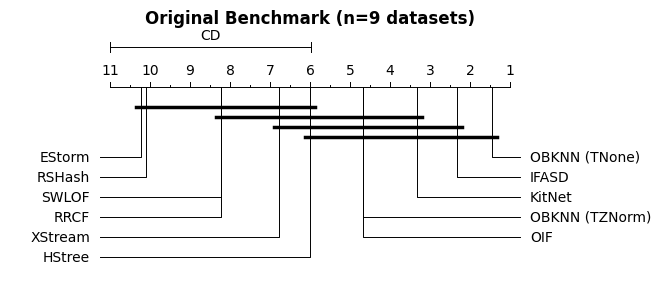

Generated cdd_original.pdf (n=9 datasets)
                meanrank    median       mad  ci_lower  ci_upper effect_size  \
EStorm          9.470588  0.127573  0.102208  0.023674  0.255337         0.0   
RSHash          9.294118  0.120093  0.085561  0.017612  0.255337    0.053527   
SWLOF           7.470588  0.208826  0.058536  0.057939  0.362135   -0.658026   
RRCF            7.294118  0.179859  0.035278  0.053525   0.32173   -0.461262   
XStream         6.882353  0.372589  0.195749   0.04023  0.720693   -1.058365   
HStree          6.352941  0.625678  0.339621  0.015967  0.967796   -1.339646   
OBKNN (TZNorm)  5.411765  0.773081  0.207341  0.053119  0.980422   -2.663621   
OIF             4.705882  0.613901   0.27288  0.061049  0.991003   -1.591989   
KitNet          4.470588  0.922869  0.075947  0.043091  0.999869   -5.957568   
IFASD           2.705882  0.967971  0.031885  0.112665  0.999962   -7.487267   
OBKNN (TNone)   1.941176  0.995034  0.004882  0.115079  0.999994   -8.086495  

<Figure size 1200x300 with 0 Axes>

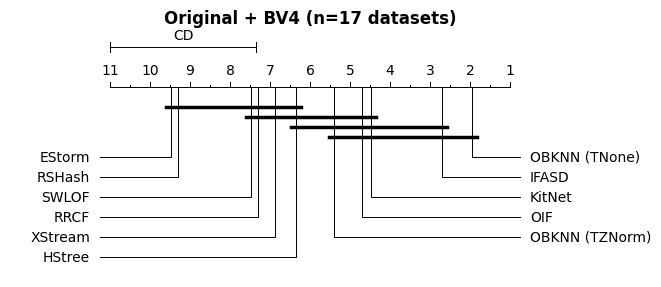

Generated cdd_original_bv4.pdf (n=17 datasets)
                meanrank    median       mad  ci_lower  ci_upper effect_size  \
EStorm          9.310345  0.127573  0.102208  0.023674  0.255337         0.0   
RSHash          9.034483  0.118323  0.083885  0.021523  0.255337    0.066732   
XStream         7.379310  0.205088  0.164859  0.042709  0.692581   -0.381187   
RRCF            7.206897  0.164393  0.042724  0.065768  0.316508    -0.31704   
SWLOF           6.896552  0.191122  0.056097  0.074089  0.287388   -0.519915   
HStree          6.310345  0.230357  0.222535  0.015967  0.962575   -0.400365   
OBKNN (TZNorm)  5.448276  0.207744  0.150941   0.07484  0.970406   -0.419508   
KitNet          4.896552  0.499342   0.40245  0.096892  0.996044   -0.854043   
OIF             4.448276  0.509710   0.30828   0.07803  0.981454   -1.122324   
IFASD           2.655172  0.882891  0.116966  0.126309  0.999787   -4.638367   
OBKNN (TNone)   2.413793  0.993381  0.006543  0.140062  0.999924   -8.063

<Figure size 1200x300 with 0 Axes>

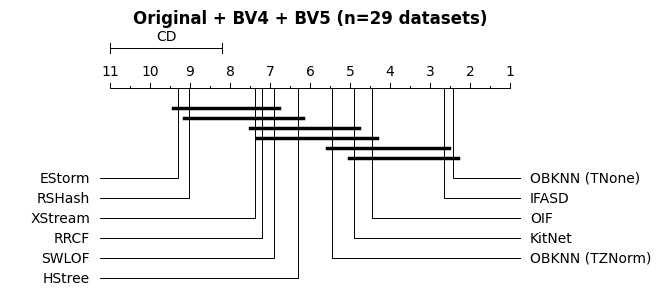

Generated cdd_all.pdf (n=29 datasets)


In [17]:
# --------------------------------------------------
# Additional scenario groups
# --------------------------------------------------

degassing_scenarios = {
    "HNH", "HAR",
    "LNH", "LAR",
    "RNH", "RAR", "RMX"
}

# --------------------------------------------------
# Pretty titles
# --------------------------------------------------

title_map = {
    "original": "Original Benchmark",
    "original_bv4": "Original + BV4",
    "all": "Original + BV4 + BV5"
}

# --------------------------------------------------
# Build datasets
# Only keep:
#   1. Original
#   2. Original + BV4
#   3. Original + BV4 + BV5 (all)
# --------------------------------------------------

datasets = {

    # Original only
    "original":
        data[
            data["benchmark"] == "Original Spectral Benchmark"
        ],

    # Original + BV4
    "original_bv4":
        data[
            data["benchmark"].isin(
                ["Original Spectral Benchmark", "BV4"]
            )
        ],

    # Original + BV4 + BV5
    "all":
        data[
            data["benchmark"].isin(
                ["Original Spectral Benchmark", "BV4", "BV5"]
            )
        ]
}

# --------------------------------------------------
# Generate CDDs
# --------------------------------------------------

output_dir = current_dir / "notebooks" / "img_cdd"

for name, subset in datasets.items():

    mean_pivot = subset.pivot_table(
        values="vus_pr",
        index="cod_scenario",
        columns="method",
        aggfunc="mean"
    )

    n_datasets = mean_pivot.shape[0]

    if n_datasets < 2:
        print(f"Skipping {name}: only {n_datasets} datasets")
        continue

    result = autorank(
        mean_pivot,
        alpha=0.05,
        verbose=False,
        order="descending"
    )

    plt.figure(figsize=(12, 3))

    plot_stats(
        result,
        allow_insignificant=False
    )

    plt.suptitle(
        f"{title_map[name]} (n={n_datasets} datasets)",
        fontsize=12,
        fontweight="bold",
        y=1.05
    )

    plt.savefig(
        output_dir / f"cdd_{name}.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Generated cdd_{name}.pdf "
        f"(n={n_datasets} datasets)"
    )

## Summary Training Time of Online Anomaly Detectors with PV Datasets 

In [18]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="mean_training_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="mean_training_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_848611/1826925235.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_848611/1826925235.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


cod_scenario                                                                                                                                                                                                                                                                                                                                                          A1  \
window_size                                                                                                                                                                                                                                                                                                                                                          210   
method_and_year       parameters                                                                                                                                                                                                                                                                                                                                           
OIF (2024)            {'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}                                                                                                                                                                                                                                     NaN   
XStream (2018)        {'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}                                                                                                                                                                                                                                                                    NaN   
KitNet (2018)         {'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}                                                                                                                                                                                                                                              0.095 ± 6.6e-05   
IFASD (2013)          {'initial_window_X': None, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                               NaN   
RRCF (2016)           {'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}                                                                                                                                                                                                                                                                                       NaN   
OBKNN (TZNorm) (2025) {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}              NaN   
OBKNN (TNone) (2025)  {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}                  NaN   
RSHash (2011)         {'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}                                                                                                                                                                                                              NaN

## Summary Scoring Time of Online Anomaly Detectors with PV Datasets 

In [19]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="mean_scoring_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="mean_scoring_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_848611/3238025577.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_848611/3238025577.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


cod_scenario                                                                                                                                                                                                                                                                                                                                                          A1  \
window_size                                                                                                                                                                                                                                                                                                                                                          210   
method_and_year       parameters                                                                                                                                                                                                                                                                                                                                           
XStream (2018)        {'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}                                                                                                                                                                                                                                                                    NaN   
KitNet (2018)         {'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}                                                                                                                                                                                                                                              0.089 ± 8.5e-05   
OBKNN (TZNorm) (2025) {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}              NaN   
OBKNN (TNone) (2025)  {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}                  NaN   
OIF (2024)            {'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}                                                                                                                                                                                                                                     NaN   
SWLOF (2000)          {'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}                                                                                                                                                                                                                                                NaN   
IFASD (2013)          {'initial_window_X': None, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                               NaN   
EStorm (2007)         {'max_radius': 900, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                                      NaN